In [19]:
import numpy as np
USE_PROPACK = True
import scipy as sp
# import jax.numpy as jnp
import matplotlib.pyplot as plt
import healpy as hp
import camb
import os
import time
from tqdm import tqdm

In [3]:
root_dir = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01'
obsmat_SAT4_f030_coadd = 'sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix.npz'
ivar_f030_coadd = 'sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits'


In [4]:
mask = hp.read_map('/pscratch/sd/j/jost/SO_MEGATOP/MSS2/Coadd_fsky0.19/masks/binary_mask.fits')

(4, 4101)


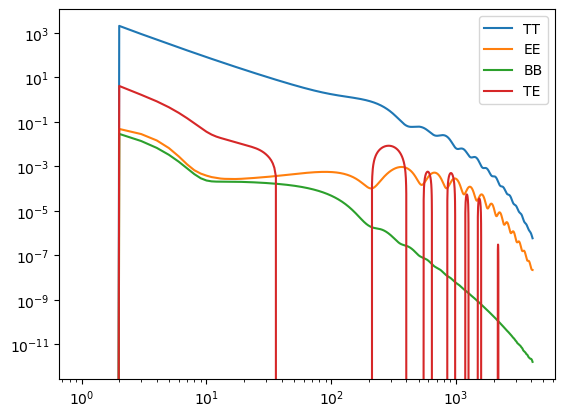

In [5]:
cmb_spectra = hp.read_cl('/global/homes/j/jost/Megatop/fiducial_cmb_spectra/Cls_Planck2018_unlensed_scalar_and_tensor_r1.fits')
print(cmb_spectra.shape)
ell = np.arange(0, len(cmb_spectra[0]))
plt.plot(ell, cmb_spectra[0,:], label='TT')
plt.plot(ell, cmb_spectra[1,:], label='EE')
plt.plot(ell, cmb_spectra[2,:], label='BB')
plt.plot(ell, cmb_spectra[3,:], label='TE')
plt.loglog()
plt.legend()
plt.show()

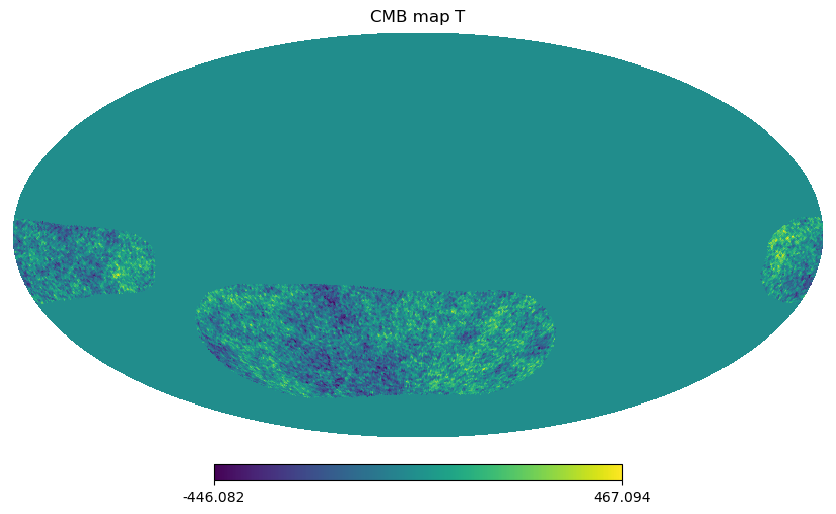

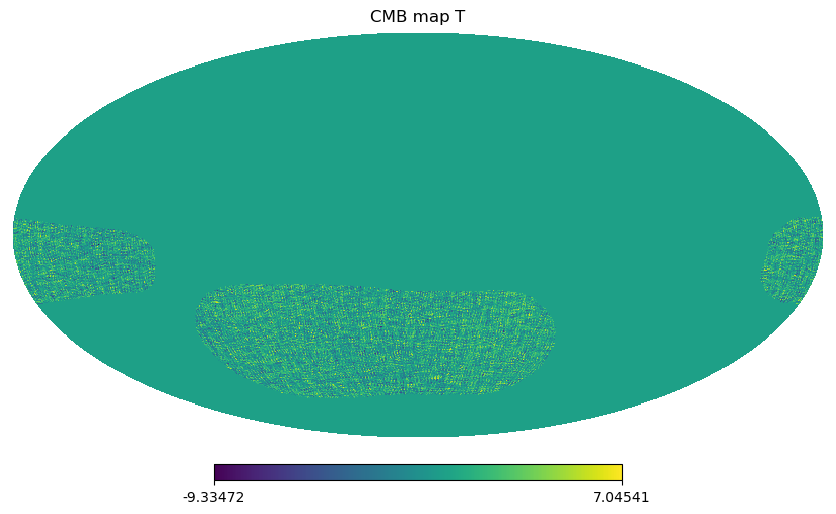

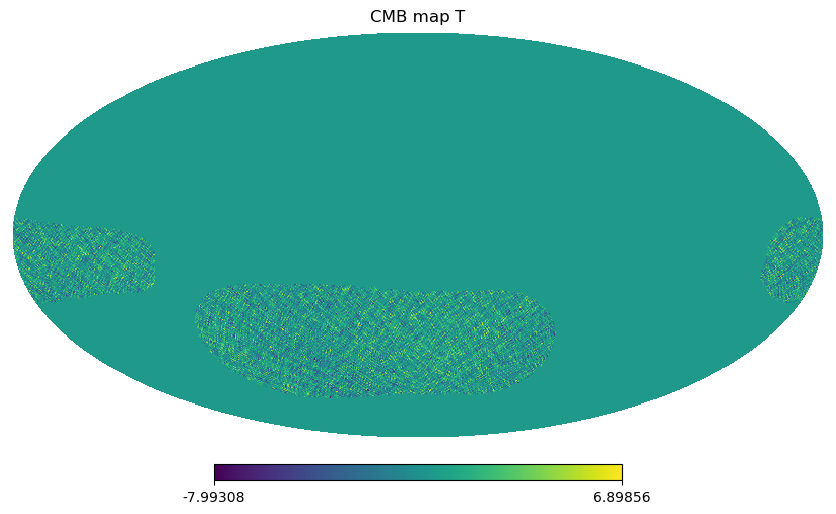

In [6]:
#  create CMB map:
nside = 128
cmb_map = hp.synfast(cmb_spectra, nside, new=True) 
cmb_map[..., np.where(mask == 0)] = 0

hp.mollview(cmb_map[0], title='CMB map T')
plt.show()
hp.mollview(cmb_map[1], title='CMB map T')
plt.show()
hp.mollview(cmb_map[2], title='CMB map T')
plt.show()


In [7]:
%%time
# Loading obs matrix
path_observation_matrix = os.path.join(root_dir, obsmat_SAT4_f030_coadd)
print(path_observation_matrix)
obs_matrix_sparse = sp.sparse.load_npz(path_observation_matrix)

/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix.npz
CPU times: user 1min 5s, sys: 8.77 s, total: 1min 14s
Wall time: 1min 15s


In [8]:

def apply_obs_mat(map, obs_mat):
    nested_map = hp.reorder(map, r2n=True)
    obs_dot_map = obs_mat.dot(nested_map.ravel()).reshape(3, hp.nside2npix(nside))
    ringed_obs_dot_map = hp.reorder(obs_dot_map, n2r=True)
    return ringed_obs_dot_map


In [9]:
%%time
start_standard_obs = time.time()
observed_CMB = apply_obs_mat(cmb_map, obs_matrix_sparse)
time_standard_obs = time.time() - start_standard_obs
observed_CMB[..., np.where(mask == 0)] = hp.UNSEEN

CPU times: user 1.7 s, sys: 12.4 ms, total: 1.71 s
Wall time: 1.72 s


In [10]:
# Computing spectra
cl_cmb_observed = hp.anafast(observed_CMB)

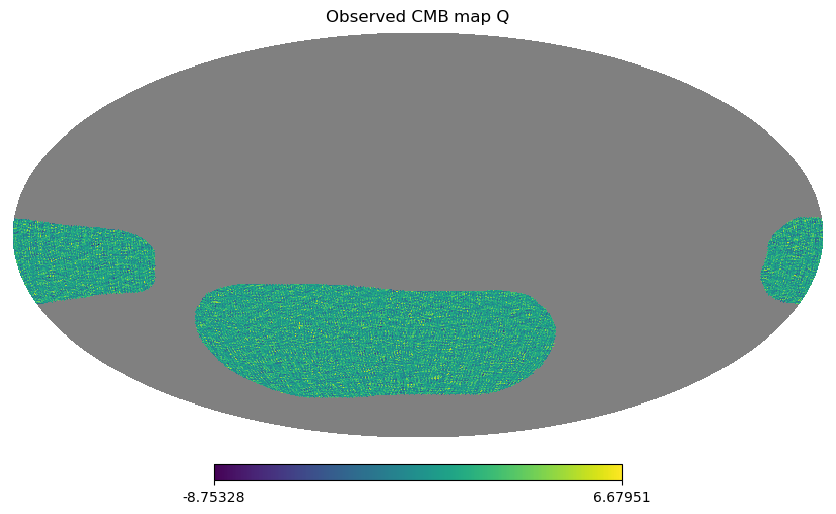

In [11]:
hp.mollview(observed_CMB[1], title='Observed CMB map Q')#, min=-10, max=10)
plt.show()


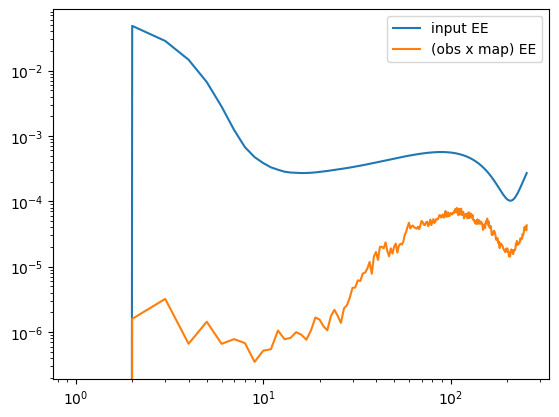

In [12]:
lmax = nside*2
ell = np.arange(0, lmax)

plt.plot(ell, cmb_spectra[1,:lmax], label='input EE')
plt.plot(ell, cl_cmb_observed[1,:lmax], label='(obs x map) EE')
plt.loglog()
plt.legend()

plt.show()

In [13]:
np.save('cmb_spectra_test_svd.npy', cmb_spectra)
np.save('cl_cmb_observed_test_svd.npy', cl_cmb_observed)


In [14]:
fraction_tokeep = 0.0001
k_svd = int(obs_matrix_sparse.shape[0]* fraction_tokeep)
print(k_svd)

k_svd = [3] #, 60]
fraction_kept = [k_svd[i]/obs_matrix_sparse.shape[0] for i in range(len(k_svd))]
print(fraction_kept)

threshold_sparse = 1e-5


58
[5.086263020833333e-06]


In [15]:
def apply_threshold_sparse(matrix, threshold):
    mask = np.abs(matrix.data) < threshold
    matrix.data[mask] = 0
    matrix.eliminate_zeros()
    
    return matrix

In [16]:
def get_reduce_obs_mat_svd(obs_matrix_sparse, k_svd, svd_kwargs={}):
    u, s, vh = sp.sparse.linalg.svds(obs_matrix_sparse, k=k_svd, **svd_kwargs)


    print('u.shape = ', u.shape)
    print('s.shape = ' , s.shape)
    print('vh.shape = ', vh.shape)

    # converting u and vh to sparse matrices
    u[np.abs(u) < threshold_sparse] = 0
    vh[np.abs(vh) < threshold_sparse] = 0
    u_sparse = sp.sparse.csr_matrix(u)
    vh_sparse = sp.sparse.csr_matrix(vh)
    print(u_sparse.shape, vh_sparse.shape)
    print(type(u_sparse), type(vh_sparse))
    # u_dot_s = u_sparse @ np.diag(s)

    u_dot_s_sparse = u_sparse @ sp.sparse.diags(s)
    print(u_dot_s_sparse.nnz)
    print('sparsity u_dot_s_sparse:', u_dot_s_sparse.nnz/(u_dot_s_sparse.shape[0]*u_dot_s_sparse.shape[1]))

    u_dot_s_sparse = apply_threshold_sparse(u_dot_s_sparse, threshold_sparse)
    print(u_dot_s_sparse.nnz)
    print('sparsity u_dot_s_sparse:', u_dot_s_sparse.nnz/(u_dot_s_sparse.shape[0]*u_dot_s_sparse.shape[1]))
    # svded_obs_matrix = np.dot(u_dot_s, vh)
    # svded_obs_matrix = u_dot_s @ vh_sparse 

    svded_obs_matrix_spare = u_dot_s_sparse @ vh_sparse
    print(svded_obs_matrix_spare.nnz)
    print('sparsity = ', svded_obs_matrix_spare.nnz / np.prod(svded_obs_matrix_spare.shape)) # WARNING: svded_obs_matrix_spare.size isn't the same as for numpy arrays!
    svded_obs_matrix_spare = apply_threshold_sparse(svded_obs_matrix_spare, threshold_sparse)
    print(svded_obs_matrix_spare.nnz)
    print('sparsity = ', svded_obs_matrix_spare.nnz / np.prod(svded_obs_matrix_spare.shape)) 

    return svded_obs_matrix_spare




In [20]:
time_svd_list = []
time_apply_list = []
cl_list = []

svd_kwargs = {'which': 'SM', 'solver': 'propack'}
for k in tqdm(k_svd):
    start_svd = time.time()
    svded_obs_matrix_spare = get_reduce_obs_mat_svd(obs_matrix_sparse, k, svd_kwargs=svd_kwargs)
    time_svd = time.time() - start_svd
    time_svd_list.append(time_svd)

    time_apply = time.time()
    observed_CMB_svd = apply_obs_mat(cmb_map, svded_obs_matrix_spare)
    time_apply = time.time() - time_apply
    print('time_apply', time_apply)
    time_apply_list.append(time_apply)

    observed_CMB_svd[..., np.where(mask == 0)] = hp.UNSEEN

    cl_cmb_observed_svd = hp.anafast(observed_CMB_svd)
    cl_list.append(cl_cmb_observed_svd)


  0%|          | 0/1 [00:00<?, ?it/s]


ValueError: `solver='propack'` is opt-in due to potential issues on Windows, it can be enabled by setting the `USE_PROPACK` environment variable before importing scipy

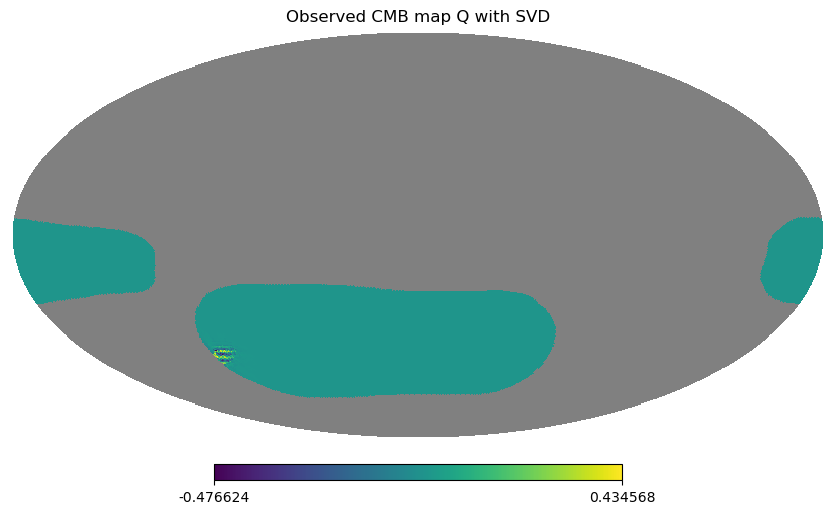

In [17]:
hp.mollview(observed_CMB_svd[1], title='Observed CMB map Q with SVD')
plt.show()

In [18]:
time_svd_list

[117.422287940979, 525.9953665733337]

In [22]:
time_apply_list

[0.02116680145263672, 0.04949808120727539]

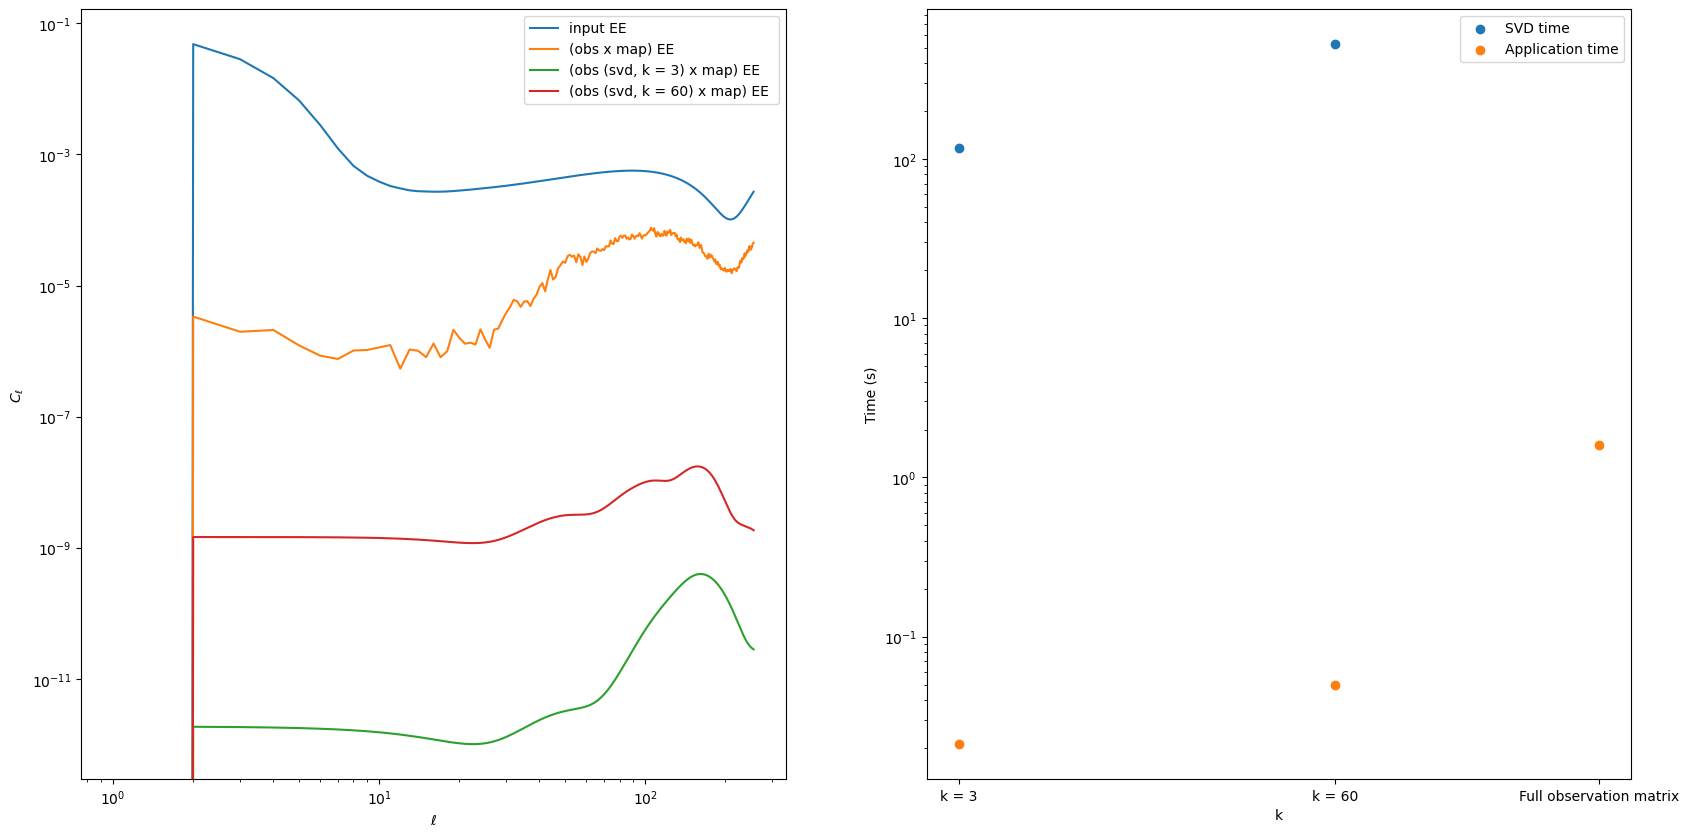

In [23]:
lmax = nside*2
ell = np.arange(0, lmax)

# Making 2 subplots, 1st with EE spectra, second with time for SVD decomp and application time

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].plot(ell, cmb_spectra[1,:lmax], label='input EE')
axs[0].plot(ell, cl_cmb_observed[1,:lmax], label='(obs x map) EE')
for i, k in enumerate(k_svd):
    axs[0].plot(ell, cl_list[i][1,:lmax], label=f'(obs (svd, k = {k}) x map) EE ')
axs[0].loglog()
axs[0].legend()
axs[0].set_ylabel(r'$C_\ell$')
axs[0].set_xlabel(r'$\ell$')

axs[1].scatter(k_svd, time_svd_list, label='SVD time')
axs[1].scatter(k_svd, time_apply_list, label='Application time')
axs[1].scatter(100, time_standard_obs, color='C1')# label='Standard application time')
# changing tick 70 to "full observation matrix"
axs[1].set_xticks(k_svd + [100])
axs[1].set_xticklabels([f'k = {k}' for k in k_svd] + ['Full observation matrix'])

axs[1].set_xlabel('k')
axs[1].set_ylabel('Time (s)')
axs[1].set_yscale('log')
axs[1].legend()

plt.show()

